# **Stroke Predictor App- Data Modelling Process**

## Objectives

* Create Modelling Dataset
* Push data through ML pipeline for predictive analytics

## Inputs

* Dataset from the "Clean Data" file, imported from Kaggle

## Outputs

* Modelling Data, stored in "Modelling Data" file
* ML Model
    * Trained
    * Tested
    * Evaluated





---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\stroke_prediction_app\\stroke_prediction_app\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\stroke_prediction_app\\stroke_prediction_app'

---

# Import Dataset and Required Packages


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE

In [5]:
clean_stroke_data_df = pd.read_csv("data_files/CleanData/stroke_data_clean.csv")
clean_stroke_data_df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
3420,Male,82,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0
3421,Female,57,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0
3422,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
3423,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0


---

# _**Machine Learning Pipeline**_

The machine learning pipeline to be implemented will be a **Supervised Learning Classification** model pipeline. This can be explained by the following:

* **Supervised Learning**:
    * Supervised learning is machine learning done off data that is already labelled.
        * **FOR EXAMPLE** : If the model is told that "Green is good and Red is bad" then as the data is labelled it will consider green to be good and red to be bad rather than coming to its own conclusions.
    * This is important in this scenario as we are predicting stroke likelihood and already have a decided variable (Stroke = 1)
* **Classification**:
    * Classification is useful as:
        1) We are not using continuous data
        2) We have categorical input data
    * This model will help for the predicitive analytics and is especially useful when using supervised learning.

## Encoding

As we will be building an ML model and analysing the impact of the variables on stroke likelihood then it is important to encode the categorical data  in new encoded coumns that are currently stored in the dataset as string values. This includes the following columns:

* Gender
* Ever Married
* Work Type
* Residence Type
* Smoking status

The first encoded columns to be created will be "Gender" ("Male" or "Female") "Ever Married" ("Yes" or "No") and "Residence Type" ("Urban" or "Rural") as they all have binary values.

In [6]:
clean_stroke_data_df["ever_married_encoded"] = clean_stroke_data_df["ever_married"].map({"Yes": 1, "No": 0})
clean_stroke_data_df["Residence_type_encoded"] = clean_stroke_data_df["Residence_type"].map({"Urban": 1, "Rural": 0})
clean_stroke_data_df["gender_encoded"] = clean_stroke_data_df["gender"].map({"Male": 1, "Female": 0})

clean_stroke_data_df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,ever_married_encoded,Residence_type_encoded,gender_encoded
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,1,1,1
1,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,1,0,1
2,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,1,1,0
3,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,1,0,0
4,Male,81,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3420,Male,82,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0,1,0,1
3421,Female,57,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0,1,0,0
3422,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,1,1,0
3423,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,1,0,0


We can see in the new dataset that the new encoded columns have been added. Next, we will have to create encoded columns for the "Work Type" and "Smoking Status" columns. These will use one-hot encoding. Essentially this will create new columns for each variable within the original columns first. For example, the "Work Type" column will create five new encoded columns for the "Private", "Self-employed" ,"Govt", "Children" and "Never worked" variables.

In [7]:
work_type_encoded_temp_df = pd.get_dummies(clean_stroke_data_df["work_type"], prefix="work_type", dtype=int)
clean_stroke_data_df = pd.concat([clean_stroke_data_df, work_type_encoded_temp_df], axis=1)
clean_stroke_data_df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,ever_married_encoded,Residence_type_encoded,gender_encoded,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,1,1,1,0,0,1,0,0
1,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,1,0,1,0,0,1,0,0
2,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,1,1,0,0,0,1,0,0
3,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,1,0,0,0,0,0,1,0
4,Male,81,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3420,Male,82,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0,1,0,1,0,0,0,1,0
3421,Female,57,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0,1,0,0,0,0,1,0,0
3422,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,1,1,0,0,0,0,1,0
3423,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,1,0,0,0,0,0,1,0


The columns have been added to the original dataframe by creating a temporary dataframe and concatenating it with the original dataframe. Now, to do the same with the "Smoking Status" column.

In [8]:
smoking_status_encoded_temp_df = pd.get_dummies(clean_stroke_data_df["smoking_status"], prefix="smoking_status",dtype= int)
clean_stroke_data_df = pd.concat([clean_stroke_data_df, smoking_status_encoded_temp_df], axis=1)
clean_stroke_data_df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,...,Residence_type_encoded,gender_encoded,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,...,1,1,0,0,1,0,0,1,0,0
1,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,...,0,1,0,0,1,0,0,0,1,0
2,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,...,1,0,0,0,1,0,0,0,0,1
3,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,...,0,0,0,0,0,1,0,0,1,0
4,Male,81,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,...,1,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3420,Male,82,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,...,0,1,0,0,0,1,0,0,1,0
3421,Female,57,0,0,Yes,Private,Rural,77.93,21.7,never smoked,...,0,0,0,0,1,0,0,0,1,0
3422,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,...,1,0,0,0,0,1,0,0,1,0
3423,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,...,0,0,0,0,0,1,0,0,1,0


---

## Create new Dataframe from new dataset

Next, we will export the dataset as a new dataset and create a new dataframe from this dataset, primarly for modelling.

In [9]:
clean_stroke_data_df.to_csv("data_files/ModellingData/stroke_data_modelling.csv", index=False)

In [10]:
stroke_modelling_df = pd.read_csv("data_files/ModellingData/stroke_data_modelling.csv")
stroke_modelling_df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,...,Residence_type_encoded,gender_encoded,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,...,1,1,0,0,1,0,0,1,0,0
1,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,...,0,1,0,0,1,0,0,0,1,0
2,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,...,1,0,0,0,1,0,0,0,0,1
3,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,...,0,0,0,0,0,1,0,0,1,0
4,Male,81,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,...,1,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3420,Male,82,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,...,0,1,0,0,0,1,0,0,1,0
3421,Female,57,0,0,Yes,Private,Rural,77.93,21.7,never smoked,...,0,0,0,0,1,0,0,0,1,0
3422,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,...,1,0,0,0,0,1,0,0,1,0
3423,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,...,0,0,0,0,0,1,0,0,1,0


It is important to drop the non-encoded columns as these will not be required for the modelling.

In [11]:
stroke_modelling_df = stroke_modelling_df.drop(["gender","ever_married","work_type","Residence_type","smoking_status"], axis=1)
stroke_modelling_df

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,ever_married_encoded,Residence_type_encoded,gender_encoded,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67,0,1,228.69,36.6,1,1,1,1,0,0,1,0,0,1,0,0
1,80,0,1,105.92,32.5,1,1,0,1,0,0,1,0,0,0,1,0
2,49,0,0,171.23,34.4,1,1,1,0,0,0,1,0,0,0,0,1
3,79,1,0,174.12,24.0,1,1,0,0,0,0,0,1,0,0,1,0
4,81,0,0,186.21,29.0,1,1,1,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3420,82,1,0,71.97,28.3,0,1,0,1,0,0,0,1,0,0,1,0
3421,57,0,0,77.93,21.7,0,1,0,0,0,0,1,0,0,0,1,0
3422,81,0,0,125.20,40.0,0,1,1,0,0,0,0,1,0,0,1,0
3423,35,0,0,82.99,30.6,0,1,0,0,0,0,0,1,0,0,1,0


---

## Define the Features and Target 

From the new dataframe it is important that we define what the features are and what the target is.

In [12]:
X = stroke_modelling_df.drop(["stroke"], axis = 1)
y = stroke_modelling_df["stroke"]

The "X" represents the features and requires the dropping of the "stroke" column. "X" is capitalised as it represents that it is a matrix and this is considered ML convention. The "y" is the "stroke" column as this is the variable that we are predicting and so the target.

---

## Train-Test Split

A Train-test split is a method where data is split into two groups:

* Train - this group is the training set and will train the model on the dataset.
* Test - this group is the testing set and will test the trained model against the dataset.

This method allows us to build a more robust model that is more reliable when testing it against new data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=18 )

* Train-test split ratio selected is 80:20
* "Random State" value was selected as "18". This is so that whenever the script is run, the same information is used when doing the train-test split and the results can be reproducible.

---

## Class Imbalance*

In this dataset there is an imbalance between the amount of records for "Stroke" and "No Stroke" history individuals. This known as a class imbalance. When dealing with data that is financial or medical, it is common to experience this but also necessary to deal with the class imbalance to prevent false negatives or positives. To deal with this we will be using Synthetic Minority Over-sampling Technique or SMOTE. This will create synthetic data for the minority class (in this case the "Stroke" class). It will work by selecting minority instances, finding similar neighbour records and creating new synthetic values. This will prevent overfitting by the ML model.

In [53]:
#    smote = SMOTE(random_state=68)
#    X_train, y_train = smote.fit_resample(X_train,y_train)

A random seed value of "68" was selected. It is essential to maintain the same values generated by the SMOTE so that is why it has not been left blank. If it was left blank then the SMOTE generated values would change everytime the script was run.
The dataset has been resampled and is ready for the next stage of the pipeline.

# *___IMPORTANT NOTE___

Initially after identifying the class imbalance, SMOTE was used to deal with this. The SMOTE had been written to run prior to the Train-Test split method. As this occurred, a result of 92% accuracy was being seen by the model evaluations for the Random forest model. This was a mistake as it meant that the evaluation was occurring on synthetic data therefore giving artificial results. When the two methods were switched, the evaluation was much more reliable however, none of the models were giving good results for accuracy. To test a different method for balancing other than SMOTE, the SMOTE method was commented out and "class_weight ="balanced"" was used when training the models (See Training of Models section below). As SMOTE was used as part of the pipeline originally it has been kept in the notebook as part of ML pipeline analysis.

---

## Scaling of Numerical values

Scaling is required as there are a variety of numerical values with a variety of ranges. A quick "describe()" function will display the ranges of the numerical values in the dataset under the "min" and "max" columns.

In [15]:
stroke_modelling_df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,ever_married_encoded,Residence_type_encoded,gender_encoded,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
count,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000
mean,48.652555,0.119124,0.060146,108.311670,30.292350,0.052555,0.758832,0.509489,0.390949,0.150073,0.004088,0.642336,0.183650,0.019854,0.244088,0.540730,0.215182
std,18.850018,0.323982,0.237792,47.706754,7.295778,0.223175,0.427854,0.499983,0.488034,0.357195,0.063813,0.479383,0.387255,0.139519,0.429608,0.498411,0.411009
min,10.000000,0.000000,0.000000,55.120000,11.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,0.000000,0.000000,77.230000,25.300000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,0.000000,0.000000,92.350000,29.100000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,63.000000,0.000000,0.000000,116.200000,34.100000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,82.000000,1.000000,1.000000,271.740000,92.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Age, Average glucose level and BMI all have large ranges with their max values at 82, 271.74 and 92 respectively. This would cause the model to put more weight on these values. This would create an incorrect model. To counter this issue, scaling is involved.

In [16]:
stroke_scaler = StandardScaler()
X_train = stroke_scaler.fit_transform(X_train)
X_test = stroke_scaler.transform(X_test)

The training data requires the "fit_transform()" function as it is learning the parameters from the data and then will apply the learnt parameters. The test data will ONLY need the "transform" function as it is only applying the learnt paramaters and will not do any learning.

---

## Training of Models

The next stage is to train models against the newly structured modelling data. All three models being used are common to classification modelling. The three models that we will be training are as follows:

* Logistic Regression - This is a classification algorithm that predicts the probability of binary outcomes based off of input variables.
* Decision Tree - This is a classification algorithm that is a combination of decisions.
* Random Forest - This is a classification algorithm that averages multiple different decision trees based off of input variables with the goal to reduce variance.


In [17]:
lr_model = LogisticRegression(random_state=46, class_weight= "balanced")
rf_model = RandomForestClassifier(random_state=92, class_weight= "balanced")
dt_model = DecisionTreeClassifier(random_state=11, class_weight="balanced")

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=11)

As mentioned above in the "Class Imbalance" section, "class_weight= "balanced"" has been used to balance the classes as part of all the models. The difference in the use of both is as follows:

* SMOTE - SMOTE creates synthetic data based off of the original dataset. In this scenario it would create more records for the "Stroke = Yes" class as that is the minority class.
* Class Weight method - This method **DOES NOT** create more data or synthetic data. It is applied as part of the model training and pushes the model to penalise itself more for when it makes a mistake in classifying data. This pushes the model to be better at improving itself when it makes mistakes.

---

## Model Evaluation

Once the models have been trained it is essential to evaluate the accuracy of all the models to decide which model is best to use in this project. The first thing to be done will be to create a "For" loop in which the evaluation metrics will run through each model. This is more efficient than testing the model one by one as the "For" loop will do this automaticcally until all the models are evaluated.

In [ ]:
for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model), ("Decision Tree", dt_model)]:
    y_prediction = model.predict(X_test)
    print(f"\n{name}")
    print(f"Accuracy: {accuracy_score(y_test, y_prediction):.2f}")
    print(classification_report(y_test, y_prediction))


Logistic Regression
Accuracy: 0.72
              precision    recall  f1-score   support

           0       0.98      0.71      0.83       975
           1       0.13      0.79      0.22        53

    accuracy                           0.72      1028
   macro avg       0.56      0.75      0.53      1028
weighted avg       0.94      0.72      0.80      1028


Random Forest
Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       975
           1       0.00      0.00      0.00        53

    accuracy                           0.95      1028
   macro avg       0.47      0.50      0.49      1028
weighted avg       0.90      0.95      0.92      1028


Decision Tree
Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       975
           1       0.08      0.06      0.07        53

    accuracy                           0.92      1028
   macro avg       0.51      0.5

Each Model was assessed against a variety of criteria:

* Precision - this measures how precise the model is in terms of predicting strokes. It is compared to how many strokes were real.
* Recall - this measures how many of the actual strokes documented were caught by the model
* F1-score - this calculates the balance of Precision and Recall. A high F1 score means that the model is really good with high precision and high recall.

This is what the results displayed for each model:

* Logistic Regression model:
    * This model showed an overall accuracy of 72%
    * The Precision at predicting strokes was 13%
    * The Recall at identifying real stroke records was 79%
    * The F1-score was about 22%
    * Overall, the model was good at recalling and identifying true strokes but had very low precision.
* Random Forest model:
    * This model showed an overall accuracy of 95%
    * The Precision was 0%
    * The Recall was 0%
    * The F1-score was 0%
    * Overall, this model was terrible at predicting and identifying "Stroke = Yes" scenarios. The reason this model had an accuracy of 95% was that it was able to identify "Stroke= No" scenarios. This means that the accuracy result of this model is not reliable, especially in this case as it is important for the evaluation scores to be higher for the "Stroke = Yes" section.
* Decision Tree model:
    * This model showed an overall accuracy of 92%
    * The Precision was at 8%
    * The Recall was at 6%
    * The F1-score was at 7%
    * Overall, this model was the 2nd worst model out of the three in predicting and identifying "Stroke = Yes" scenarios. Similar to the Random Forest model, this model was good at identifying "Stroke= No" scenarios but not the converse, which is more important for this dataset.


As a result of the above evaluation it is decided that the Logistic Regression Model is the best out of the three models to predict stroke likelihood.

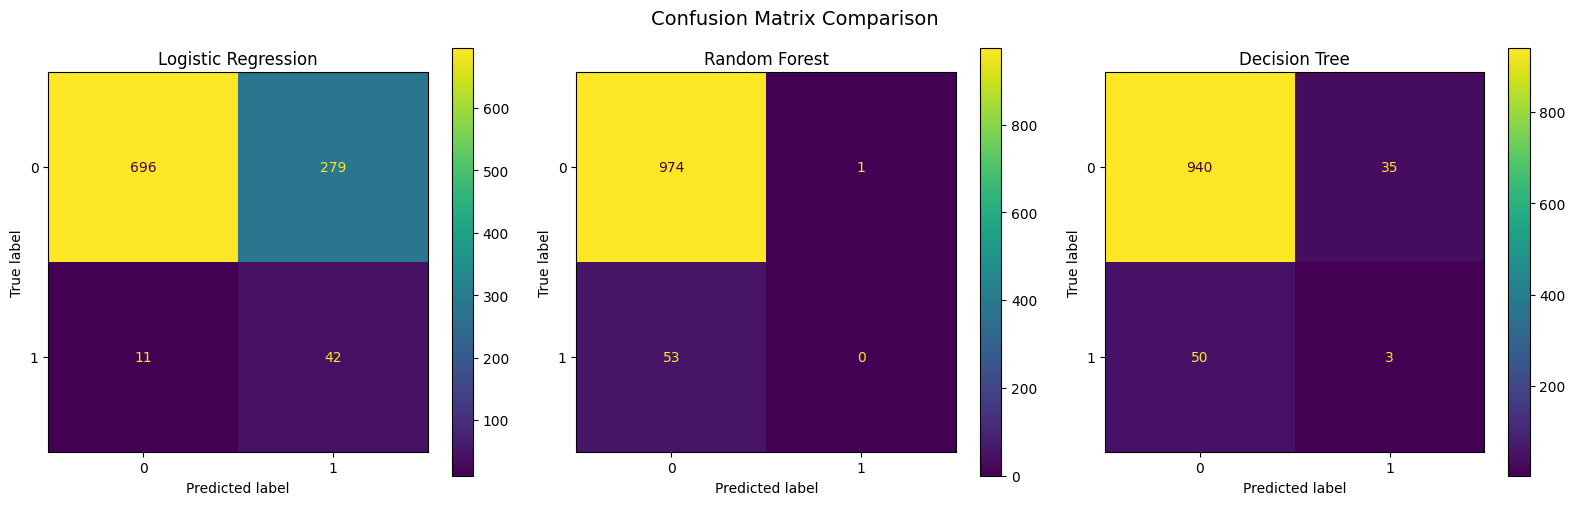

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, [("Logistic Regression", lr_model), ("Random Forest", rf_model), ("Decision Tree", dt_model)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title(f"{name}")

plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.show()

The above confusion matrices help assess the models abilities for comparing predicted values against true values. The confusion matrix shows:

* 1-1 : True Positives
* 1-0 : False Negatives
* 0-1 : False Positives
* 0-0 : True Negatives

We can see that the Logistic Regression model showed the most True Positives and False Negatives. The True positives are essential as this shows that it was able to identify more "Stroke = Yes" cases.

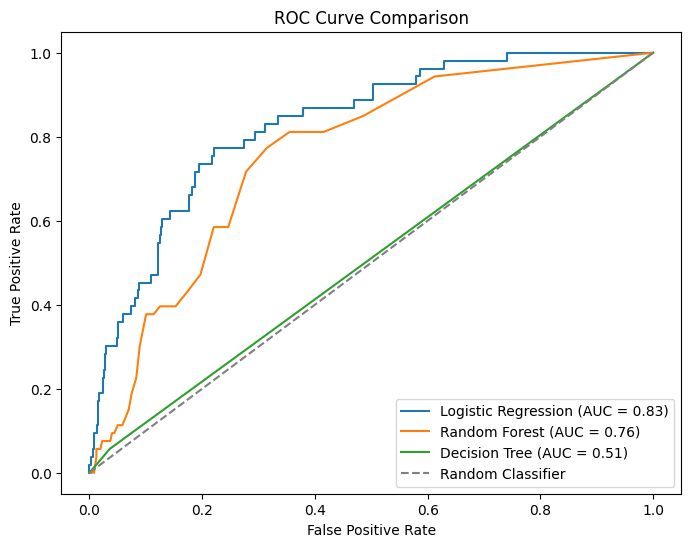

In [32]:
plt.figure(figsize=(8, 6))

for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model), ("Decision Tree", dt_model)]:
    y_probability = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probability)
    auc = roc_auc_score(y_test, y_probability)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The above figure shows an ROC Curve comparison. ROC stands for Reciever Operating Characteristic. This evaluates the performance of binary classification models. The area under curve (AUC) is calculated to give a score to each model. The higher the AUC the better the model performed. We can see that the Logistic Regression model perfomed best out of the three models with a score of 0.83. Without looking at the scores we can also see by looking at the graph that the line for Logistic Regression is closest to the left side of the graph. This indicates that the model was better at predicting True Positives than the other two models. Finally, a "Random Classifier" line is drawn. This represents a model that would place random guesses. This line indicates that any line above this would be a better model than random guessing.

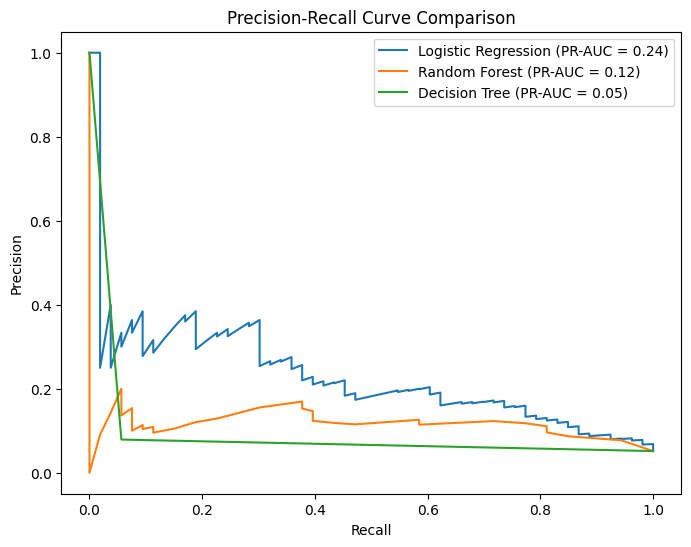

In [34]:
plt.figure(figsize=(8, 6))

for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model), ("Decision Tree", dt_model)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

Above is a PR-AUC graph or a Precision-Recall Area Under Curve graph. Unlike the ROC-AUC graph, this allows us to compare the models more specifically against the minority class rather than the assessing overall model performance. This is better to use when evaluating imbalanced datasets. To assess the model scores against the baseline for this dataset it is first important to calculate the baseline.

In [36]:
baseline = y_test.sum() / len(y_test)
print(f"Baseline PR-AUC: {baseline:.2f}")

Baseline PR-AUC: 0.05


We can see that the baseline for the dataset is: 0.05. The evaluation of each model is as follows:

* Logistic Regression - The AUC score for this was 0.24. This means that this model was the best at detecting stroke occurrences.
* Random Forest - The AUC score for this was 0.12. This means that this was a poor model at predicting but was still better than random guessing.
* Decision Tree - The AUC score for this was 0.05. This means that this model was the worst and is almost no better than random guessing as it is the same as the baseline value.

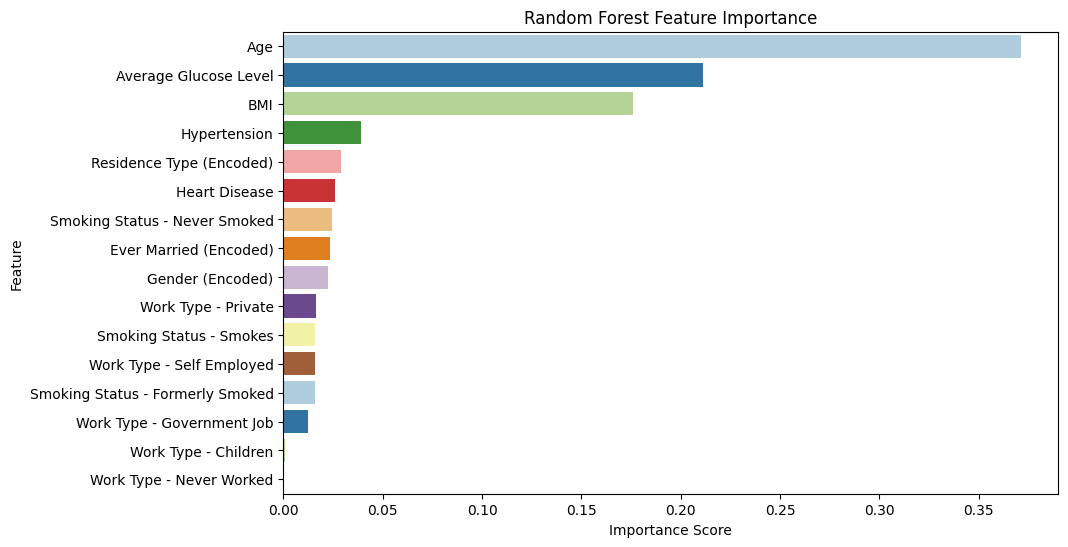

In [55]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue =feature_importance.index,  palette="Paired", legend= False)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.yticks(ticks=[0, 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15], labels=["Age", "Average Glucose Level", "BMI", "Hypertension", 
                                                                   "Residence Type (Encoded)", "Heart Disease", "Smoking Status - Never Smoked", 
                                                                   "Ever Married (Encoded)", "Gender (Encoded)", "Work Type - Private", 
                                                                   "Smoking Status - Smokes", "Work Type - Self Employed", 
                                                                   "Smoking Status - Formerly Smoked", "Work Type - Government Job", 
                                                                   "Work Type - Children", "Work Type - Never Worked"])
plt.show()

The Random Forest Feature importance chart measures how much each feature contirbutes to the model's prediction accuracy. It can help identify the most influential features. We can see that the choice of the model's feature importance is what led to the model having low to none reliable accuracy for this dataset.

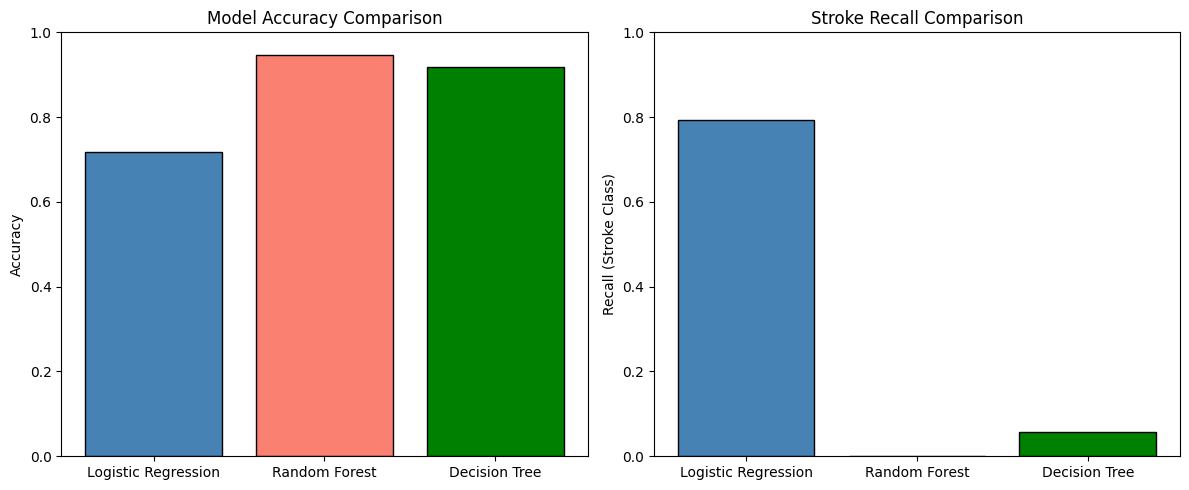

In [ ]:
model_names = ["Logistic Regression", "Random Forest", "Decision Tree"]
accuracies = []
recalls = []

for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model), ("Decision Tree", dt_model)]:
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
    recalls.append(classification_report(y_test, y_pred, output_dict=True)["1"]["recall"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(model_names, accuracies, color=["steelblue", "salmon", "green"], edgecolor="black")
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(model_names, recalls, color=["steelblue", "salmon", "green"], edgecolor="black")
axes[1].set_title("Stroke Recall Comparison")
axes[1].set_ylabel("Recall (Stroke Class)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

The above charts show a side by side comparison of the models in terms of their accuracy and recall. As explained earlier in this section, the model accuracies are not an accurate representation of the viability of the models for this dataset. The Random Forest model is shown to be the most accurate model however, when tested on "Stroke recall", the Logisitic Regression model is returning the most promising results.

---

## Export Model

In [57]:
import joblib
import os

joblib.dump(lr_model, "model/lr_model.pkl")
joblib.dump(stroke_scaler, "model/scaler.pkl")
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)

X_test_df.to_csv("model/X_test.csv", index=False)
y_test_df.to_csv("model/y_test.csv", index=False)

print("Everything saved successfully")

Everything saved successfully


To be used in the streamlit dashboard as a predictive model, it is important to export the model and the scaler to the "Model" file. From here it can be accessed for the app.